# Introduction

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [2]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [5]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
print(f"Shape: {df_data.shape}")
print(f"Rows: {df_data.shape[0]}")
print(f"Columns: {df_data.shape[1]}")
print(f"Column names: {list(df_data.columns)}")

Shape: (4324, 9)
Rows: 4324
Columns: 9
Column names: ['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price', 'Mission_Status']


In [7]:
print("Null Values")
print(f"{df_data.isnull().sum()}")
print(f"Duplicates: {df_data.duplicated().sum()}")

Null Values
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64
Duplicates: 0


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [8]:
# Remove the duplicate id columns
df_clean = df_data.drop("Unnamed: 0.1", axis="columns")
df_clean = df_clean.drop("Unnamed: 0", axis="columns")
print(df_data.columns)
print(df_clean.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='str')
Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status'],
      dtype='str')


Chosen not to remove columns with null price columns, as this would remove over half the data, and these missions can still be useful for other types of analysis

## Descriptive Statistics

In [9]:
# Average mission price
df_clean_prices = df_clean.dropna(subset=["Price"])
df_clean_prices["Price"] = df_clean_prices["Price"].str.replace(",", "")
df_clean_prices = df_clean_prices.astype({"Price": float})
print(f"${df_clean_prices["Price"].mean():.2f}")

$153.79


In [10]:
# Length of the space race
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="mixed", utc=True) # Convert date column to Datetime to make it more useful
start_date: datetime = df_clean["Date"].min()
end_date: datetime = df_clean["Date"].max()
print(f"Dates: {start_date.date()} - {end_date.date()}")

Dates: 1957-10-04 - 2020-08-07


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [11]:
# Grab the data required
launches_per_company = df_clean.groupby("Organisation").Organisation.agg(launches="count")
launches_per_company

,launches
Organisation,
AEB,3
AMBA,8
ASI,9
Arianespace,279
Arm??e de l'Air,4
Blue Origin,12
Boeing,136
CASC,251
CASIC,5


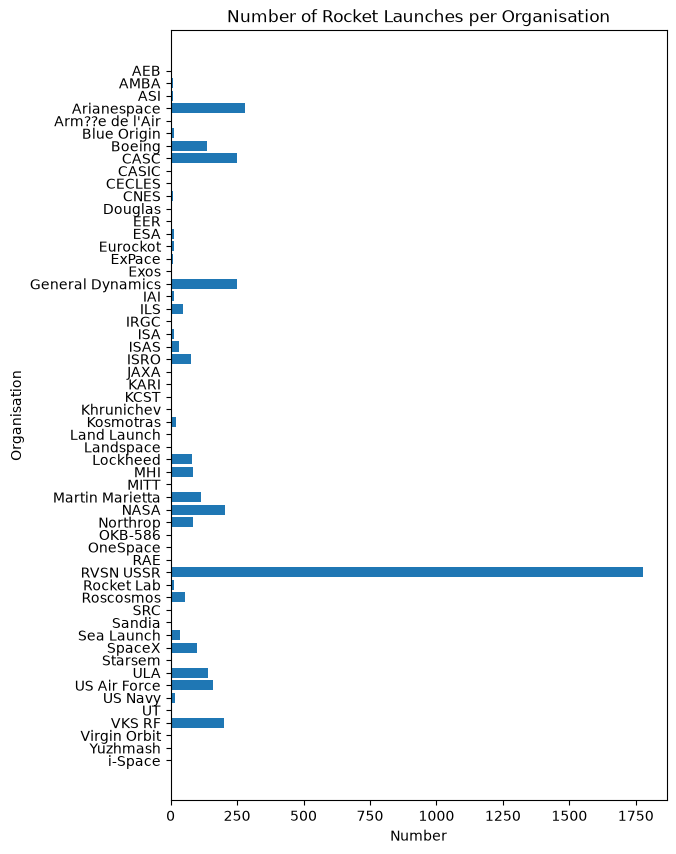

In [12]:
# Draw the graph
bar, ax = plt.subplots()

# Grab the data
companies = launches_per_company.index
launches = launches_per_company["launches"]

ax.barh(companies, launches)
ax.yaxis.set_inverted(True)
ax.set_xlabel("Number")
ax.set_ylabel("Organisation")
ax.set_title("Number of Rocket Launches per Organisation")
ax.figure.set_figheight(10)

plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [13]:
active = len(df_clean[df_clean["Rocket_Status"] == "StatusActive"])
decomissioned = len(df_clean[df_clean["Rocket_Status"] == "StatusRetired"])
print(f"Active: {active}")
print(f"Decomissioned: {decomissioned}")
print(f"There are {decomissioned - active} more decomissioned rockets than active ones")

Active: 790
Decomissioned: 3534
There are 2744 more decomissioned rockets than active ones


# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [14]:
# Percentage of successful missions
print(list(df_clean["Mission_Status"].unique()))
num_successes = len(df_clean[df_clean["Mission_Status"] == "Success"])
print(f'Successes = {num_successes}')
print(f'Failures = {len(df_clean[df_clean["Mission_Status"] != "Success"])}')
print(f'Total missions = {df_clean.shape[0]}')
print(f'{num_successes/df_clean.shape[0] * 100}% of launches are successful')

['Success', 'Failure', 'Prelaunch Failure', 'Partial Failure']
Successes = 3879
Failures = 445
Total missions = 4324
89.70860314523588% of launches are successful


# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

In [15]:
# Already got clean prices from descriptive statistics earlier
df_clean_prices["Price"]

0       50.00
1       29.75
3       65.00
4      145.00
5       64.68
        ...  
3855    59.00
3971    63.23
3993    63.23
4000    63.23
4020    63.23
Name: Price, Length: 964, dtype: float64

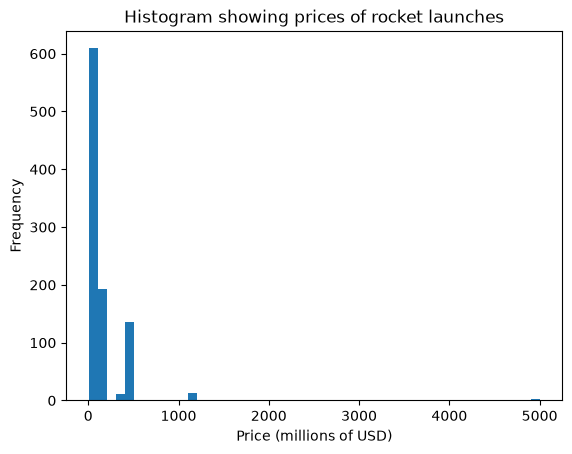

In [16]:
fig, ax = plt.subplots()

ax.hist(df_clean_prices["Price"], bins=50)
ax.set_xlabel("Price (millions of USD)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram showing prices of rocket launches")

plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [17]:
def to_country_code(location: str) -> str:
    country = location.split(",")[-1]
    country = country[1:]
    if country == "Russia" or country == "Barents Sea": country = "Russian Federation"
    elif country == "New Mexico" or country == "Gran Canaria" or country == "Pacific Missile Range Facility": country = "USA"
    elif country == "Yellow Sea": country = "China"
    elif country == "Shahrud Missile Test Site": country = "Iran"
    if country == "Iran": country = "Iran, Islamic Republic of"
    elif country == "USA": country = "United States of America"
    elif country == "North Korea": country = "Korea, Democratic People's Republic of"
    elif country == "South Korea": country = "Korea, Republic of"
    try:
        return countries.get(country).alpha3
    except: 
        print(country)
        return pd.NA

# Grab the countries in correct format
print(countries)
df_clean["Country"] = df_clean["Location"].map(to_country_code)
launches_per_country = df_clean.groupby("Country").Country.agg(launches="count")
launches_per_country


Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean
Pacific Ocean


,launches
Country,
AUS,6
BRA,3
CHN,269
FRA,303
IND,76
IRN,14
ISR,11
JPN,126
KAZ,701


In [18]:
# Draw the graph
fig = px.choropleth(launches_per_country, locations=launches_per_country.index, color="launches", hover_name=launches_per_country.index, 
                    color_continuous_scale=px.colors.sequential.Plasma, title="Number of launches per country")

fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
# Get the data in correct format
failed_launches_by_country = df_clean.loc[df_clean["Mission_Status"] != "Success"].groupby("Country").Mission_Status.agg(failed_launches="count")
print(failed_launches_by_country)

         failed_launches
Country                 
AUS                    3
BRA                    3
CHN                   25
FRA                   18
IND                   13
IRN                    9
ISR                    2
JPN                   13
KAZ                   93
KOR                    2
NZL                    2
PRK                    3
RUS                   93
USA                  163


In [25]:
# Draw the desired graph
# Draw the graph
fig = px.choropleth(failed_launches_by_country, locations=failed_launches_by_country.index, color="failed_launches", 
                    hover_name=failed_launches_by_country.index, 
                    color_continuous_scale=px.colors.sequential.Plasma, title="Number of failed launches per country")

fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

# Analyse the Amount of Money Spent by Organisation per Launch

# Chart the Number of Launches per Year

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

## Chart the Total Number of Mission Failures Year on Year.

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 